# Linear Algebra 1 — Visual Introduction

This notebook introduces the building blocks of linear algebra — visually, with working code. No prior maths knowledge is needed beyond GCSE.

Linear algebra is the maths behind search engines, image processing, machine learning, 3D graphics, and data science. By the end of this notebook you will understand the core operations that power all of those systems.

**Topics:**
- Vectors — what they are and how to draw them
- Adding vectors and scaling them
- Dot product and cross product
- Unit vectors and normalisation
- Span
- Vectors as data
- Linear transformations
- Projection

## Setup
Run this cell first — it loads all the drawing and maths helpers used throughout the notebook. You don't need to understand the helpers; just run the cell and move on.

In [2]:
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# ── Drawing helpers ───────────────────────────────────────────────────────────

def draw_vector(ax, vec, color='steelblue', label='', start=(0, 0), lw=2):
    ax.annotate('', xy=(start[0]+vec[0], start[1]+vec[1]), xytext=start,
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    if label:
        ax.text(start[0]+vec[0]*0.55, start[1]+vec[1]*0.55,
                label, color=color, fontsize=11, fontweight='bold')

def setup_axes(ax, xlim=(-1, 5), ylim=(-1, 5)):
    ax.set_xlim(*xlim);  ax.set_ylim(*ylim)
    ax.axhline(0, color='#ccc', lw=0.8)
    ax.axvline(0, color='#ccc', lw=0.8)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

# ── Maths helpers ─────────────────────────────────────────────────────────────

def magnitude(v):      return math.sqrt(sum(x**2 for x in v))
def dot(a, b):         return sum(ai*bi for ai, bi in zip(a, b))
def normalize(v):      m = magnitude(v); return [x/m for x in v]
def scalar_mul(s, v):  return [s*x for x in v]
def subtract(a, b):    return [x-y for x, y in zip(a, b)]
def mat_vec(M, v):     return [sum(M[i][j]*v[j] for j in range(len(v))) for i in range(len(M))]
def proj(u, onto):     s = dot(u, onto)/dot(onto, onto); return [s*x for x in onto]
def cross(a, b):
    return [a[1]*b[2]-a[2]*b[1], a[2]*b[0]-a[0]*b[2], a[0]*b[1]-a[1]*b[0]]

print('Ready.')

Ready.


---
## 1. Vectors

A **vector** is a list of numbers, each one measuring a different dimension of something. The list has a fixed length (its **dimension**), and the order of the numbers matters.

We draw a 2D vector as an **arrow** from the origin (0, 0) to the point the numbers describe. The two numbers are called **components**.

**Real-world examples:**

- **Directions:** `[3, 2]` means *"go 3 blocks east, then 2 blocks north."*   Every GPS instruction is a vector.
- **Pixel colour:** The colour red in RGB is the vector `[255, 0, 0]` — full   red, no green, no blue. Orange is `[255, 165, 0]`.
- **Velocity in a game:** A character moving left and up might have velocity   `[−2, 5]` — 2 units per frame left, 5 units per frame up. Change these   numbers and the character moves differently.
- **Sensor data:** A smartphone accelerometer produces a 3D vector   `[x, y, z]` describing how hard the phone is being shaken in each direction.

The key insight: **anything described by a fixed list of numbers is a vector**, and all the operations in this notebook apply to it.

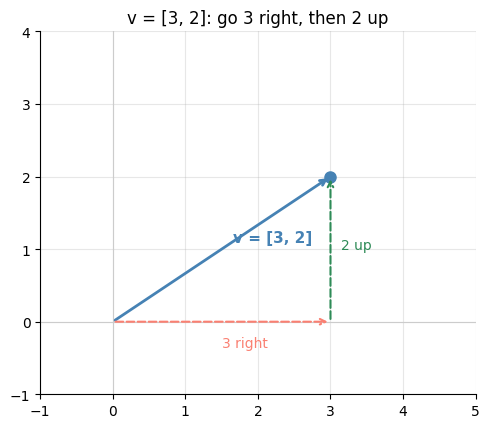

In [3]:
v = [3, 2]

fig, ax = plt.subplots(figsize=(5, 5))
draw_vector(ax, v, color='steelblue', label='v = [3, 2]')

# Dashed lines showing the two components
ax.annotate('', xy=(3, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='salmon', lw=1.5, linestyle='dashed'))
ax.annotate('', xy=(3, 2), xytext=(3, 0),
            arrowprops=dict(arrowstyle='->', color='seagreen', lw=1.5, linestyle='dashed'))
ax.text(1.5, -0.35, '3 right', color='salmon', fontsize=10)
ax.text(3.15, 1.0,  '2 up',   color='seagreen', fontsize=10)
ax.plot(*v, 'o', color='steelblue', markersize=8)

setup_axes(ax, xlim=(-1, 5), ylim=(-1, 4))
ax.set_title('v = [3, 2]: go 3 right, then 2 up', fontsize=12)
plt.tight_layout();  plt.show()

---
## 2. Vector Addition

Adding two vectors means **combining two sets of changes into one**. You add component by component:

`u + v  =  [u₁+v₁,  u₂+v₂]`

Visually: follow the first arrow all the way to its tip, then follow the second arrow from there. The sum is the **direct route** — one arrow from your starting point to your final position.

**Real-world examples:**

- **Boat crossing a river:** Your engine pushes the boat east at `[3, 0]`   metres per second. The river current pushes it north at `[0, 2]`.   Your actual movement is `[3, 0] + [0, 2] = [3, 2]` — a diagonal path   across the river. Neither force alone describes where you end up.
- **Walking in a city:** You walk 2 blocks right and 1 block up: `[2, 1]`.   Then you take a detour of `[1, 3]`. Your total displacement from your   start is `[3, 4]` — the shortcut you would have taken if you had known   the final destination.
- **Physics forces:** Two people push a box: one applies force `[5, 0]` N   (east), another `[0, 3]` N (north). The box experiences the combined force   `[5, 3]` N — vector addition gives the net force.

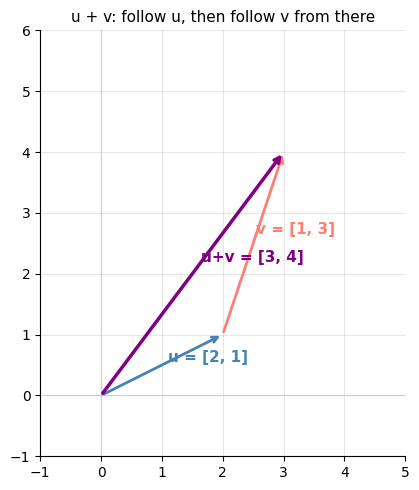

u + v = [3, 4]


In [4]:
u = [2, 1]
v = [1, 3]
result = [u[0]+v[0], u[1]+v[1]]

fig, ax = plt.subplots(figsize=(5, 5))
draw_vector(ax, u,      color='steelblue', label=f'u = {u}')
draw_vector(ax, v,      color='salmon',    label=f'v = {v}', start=tuple(u))
draw_vector(ax, result, color='purple',    label=f'u+v = {result}', lw=2.5)

setup_axes(ax, xlim=(-1, 5), ylim=(-1, 6))
ax.set_title('u + v: follow u, then follow v from there', fontsize=11)
plt.tight_layout();  plt.show()
print(f"u + v = {result}")

---
## 3. Scalar Multiplication

A **scalar** is a plain number — not a vector, just a single value. Multiplying a vector by a scalar **stretches or shrinks** every component by that amount. The direction stays the same unless the scalar is negative, in which case the vector **flips** to point the other way.

`s · v  =  [s·v₁,  s·v₂]`

**Real-world examples:**

- **Adjusting speed in a game:** A character's movement direction is stored   as the vector `[2, 1]`. Multiply by `2.0` for a sprint (`[4, 2]`), by   `0.5` to walk slowly (`[1, 0.5]`), or by `−1` to reverse (`[−2, −1]`).   The engine applies one scalar multiplication every frame.
- **Scaling a recipe:** A sauce recipe calls for `[300, 150, 50]` ml of   stock, cream, and wine. To make double the quantity, multiply the vector   by `2`: `[600, 300, 100]`. To make a taster portion, multiply by `0.25`.
- **Wind chill:** Wind speed is a 2D vector `[east, north]`. Multiplying   by a positive scalar scales how fast the wind blows without changing its   direction. Multiplying by a negative scalar models a wind reversal —   useful in weather simulation.

The crucial point: **the direction never changes** (only the length does) unless you use a negative scalar, which reverses it.

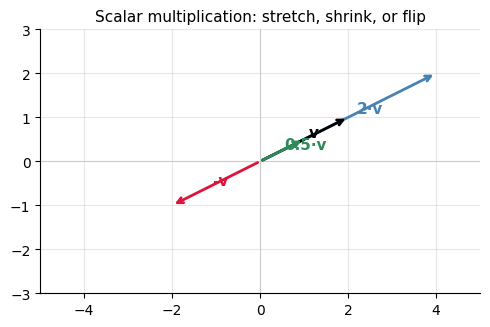

In [5]:
v = [2, 1]

fig, ax = plt.subplots(figsize=(5, 5))
for s, color, label in [(2.0, 'steelblue', '2·v'), (1.0, 'black', 'v'),
                         (0.5, 'seagreen', '0.5·v'), (-1.0, 'crimson', '-v')]:
    draw_vector(ax, scalar_mul(s, v), color=color, label=label)

setup_axes(ax, xlim=(-5, 5), ylim=(-3, 3))
ax.set_title('Scalar multiplication: stretch, shrink, or flip', fontsize=11)
plt.tight_layout();  plt.show()

---
## 4. Dot Product

The **dot product** takes two vectors and produces a **single number** by multiplying matching components and summing the results:

`a · b  =  a₁×b₁ + a₂×b₂`

That number answers a precise question: **how much do these two vectors agree on direction?** It is positive when they point the same way, zero when they are at right angles, and negative when they oppose each other.

| Result | Meaning |
|---|---|
| > 0 | Vectors point in roughly the same direction |
| = 0 | Vectors are exactly perpendicular (90° apart) |
| < 0 | Vectors point in roughly opposite directions |

**Real-world examples:**

- **Search engines:** When you search for something, your query is converted   into a vector (one number per word, based on frequency). Every webpage is   also a vector. The dot product between your query vector and a page vector   is a relevance score — the higher it is, the better the match. This is   the foundation of how Google ranks results.
- **Game AI — line of sight:** An enemy faces east, stored as direction   `[1, 0]`. You are somewhere in the scene. The game computes the dot product   of the enemy's facing direction and the vector toward you. If the result is   positive, you are in front of it; if zero, you are beside it; if negative,   you are behind it — and therefore hidden.
- **Finding angles:** The dot product also encodes the angle between vectors:   `a · b = |a| × |b| × cos(θ)`. Rearranging gives the angle directly.   This is used in robotics, physics engines, and satellite navigation to   compute how far two directions diverge.

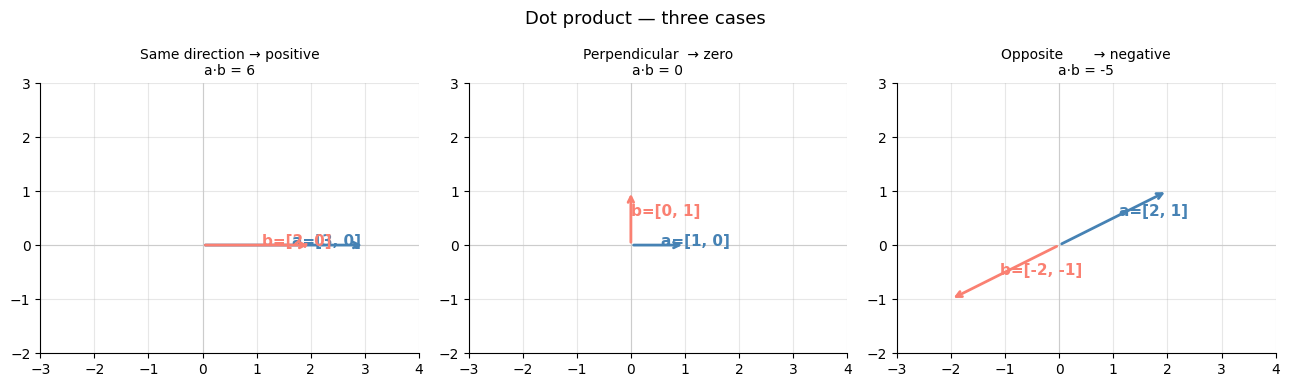

Angle between [3, 1] and [1, 3]: 53.1°


In [7]:
pairs = [
    ([3, 0], [2, 0],   'Same direction → positive'),
    ([1, 0], [0, 1],   'Perpendicular  → zero'),
    ([2, 1], [-2, -1], 'Opposite       → negative'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (a, b, title) in zip(axes, pairs):
    draw_vector(ax, a, color='steelblue', label=f'a={a}')
    draw_vector(ax, b, color='salmon',    label=f'b={b}')
    ax.set_title(f'{title}\na·b = {dot(a, b)}', fontsize=10)
    setup_axes(ax, xlim=(-3, 4), ylim=(-2, 3))

plt.suptitle('Dot product — three cases', fontsize=13)
plt.tight_layout();  plt.show()

# The dot product also reveals the angle between vectors
a, b = [3, 1], [1, 3]
angle = math.degrees(math.acos(dot(a, b) / (magnitude(a) * magnitude(b))))
print(f"Angle between {a} and {b}: {angle:.1f}°")

---
## 5. Cross Product

The **cross product** is a 3D operation. Given two vectors, it produces a **third vector that is perpendicular to both**:

`u × v  =  [u₂v₃−u₃v₂,  u₃v₁−u₁v₃,  u₁v₂−u₂v₁]`

The direction follows the **right-hand rule**: point your fingers along u, curl them toward v, and your thumb points in the direction of u × v.

The **length** of the result equals the area of the parallelogram formed by u and v.

**Real-world examples:**

- **Tightening a bolt:** When you push a spanner handle in direction u and   the bolt axis points in direction v, the cross product u × v gives the   torque vector — its direction is the axis the bolt rotates around, and   its magnitude is how hard it is being turned. This is used in every   physics engine that simulates rotating objects.
- **3D graphics — surface normals:** To light a 3D object correctly, the   graphics engine needs to know which way each triangle faces. It takes two   edges of the triangle (both vectors), computes their cross product, and   gets the outward-pointing normal. Lighting is then calculated from the   dot product of that normal with the light direction.
- **Detecting left vs. right turns:** In navigation software, the cross   product of two path segments tells you whether you turn left or right at   a junction — the sign of the z-component gives the answer.

u × v = [0, 0, 1]   ← points straight up (z-axis)


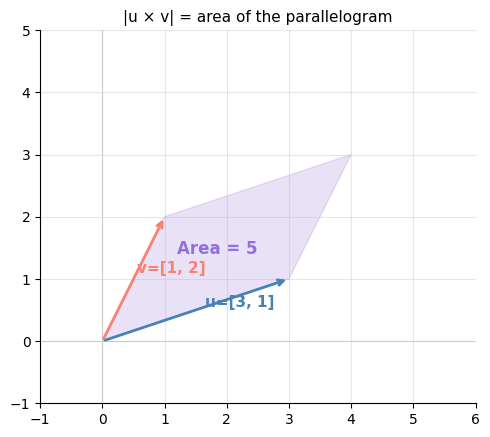

In [6]:
# 3D example: x-axis × y-axis should point along z-axis
u3 = [1, 0, 0]
v3 = [0, 1, 0]
print(f"u × v = {cross(u3, v3)}   ← points straight up (z-axis)")

# In 2D, the cross product magnitude = area of the parallelogram
u2 = [3, 1]
v2 = [1, 2]
area = abs(u2[0]*v2[1] - u2[1]*v2[0])

fig, ax = plt.subplots(figsize=(5, 5))
pts = [(0, 0), (u2[0], u2[1]), (u2[0]+v2[0], u2[1]+v2[1]), (v2[0], v2[1])]
ax.add_patch(Polygon(pts, closed=True, alpha=0.2, color='mediumpurple'))
draw_vector(ax, u2, color='steelblue', label=f'u={u2}')
draw_vector(ax, v2, color='salmon',    label=f'v={v2}')
ax.text(1.2, 1.4, f'Area = {area}', fontsize=12, color='mediumpurple', fontweight='bold')

setup_axes(ax, xlim=(-1, 6), ylim=(-1, 5))
ax.set_title('|u × v| = area of the parallelogram', fontsize=11)
plt.tight_layout();  plt.show()

---
## 6. Unit Vectors and Normalisation

A **unit vector** has length exactly 1. It represents **pure direction** — no information about magnitude, just which way to point.

To convert any vector into a unit vector, **divide every component by the vector's length**. This process is called **normalisation**:

`v̂ = v / |v|`   where `|v| = √(v₁² + v₂²)`

No matter which direction a vector points, once normalised it will land on the **unit circle** — a circle of radius 1.

**Real-world examples:**

- **Movement at a fixed speed (games):** A player clicks to move diagonally.   The engine computes the direction vector, e.g. `[3, 4]` (length = 5).   If it moved the character by `[3, 4]` pixels per frame, diagonal movement   would be 5× faster than horizontal movement. Instead it normalises:   `[3/5, 4/5] = [0.6, 0.8]` (length = 1), then multiplies by the desired   speed, e.g. 200: final velocity = `[120, 160]`. Speed is always 200,   regardless of direction.
- **Machine learning — cosine similarity:** To compare two documents by   topic rather than length, search engines normalise both document vectors   and then take their dot product. The result is the cosine of the angle   between them — 1 means identical topics, 0 means completely different.   This is called cosine similarity and it is used in every modern search   and recommendation system.
- **Computer graphics — lighting:** Shading calculations require both the   surface normal and the light direction to be unit vectors. If you forget   to normalise, surfaces closer to the light source appear artificially   brighter just because of their coordinates — a common beginner bug.

/var/folders/58/bvpmts7s2p55rx1wk3tb_kkcn1gftl/T/ipykernel_68035/2006618629.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, loc='upper left')


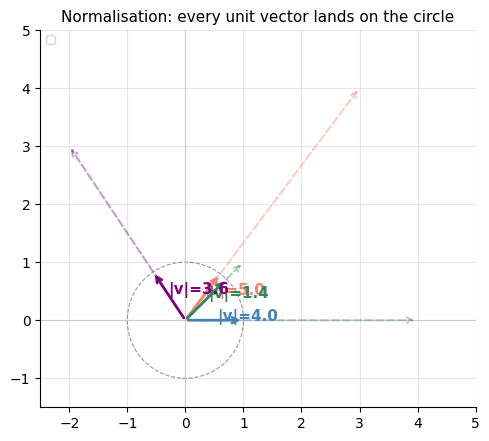

v=[4, 0]  →  v̂=[1.0, 0.0]  |v̂|=1.0000
v=[3, 4]  →  v̂=[0.6, 0.8]  |v̂|=1.0000
v=[1, 1]  →  v̂=[0.707, 0.707]  |v̂|=1.0000
v=[-2, 3]  →  v̂=[-0.555, 0.832]  |v̂|=1.0000


In [8]:
vectors = [[4, 0], [3, 4], [1, 1], [-2, 3]]
colors  = ['steelblue', 'salmon', 'seagreen', 'purple']

fig, ax = plt.subplots(figsize=(5, 5))
for vec, col in zip(vectors, colors):
    uv = normalize(vec)
    # original vector (dashed, to show the original size)
    ax.annotate('', xy=(vec[0], vec[1]), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=col, lw=1.5, linestyle='dashed', alpha=0.4))
    # unit vector (solid)
    draw_vector(ax, uv, color=col, label=f'|v|={magnitude(vec):.1f}')

# unit circle
theta = [i * 2 * math.pi / 360 for i in range(361)]
ax.plot([math.cos(t) for t in theta], [math.sin(t) for t in theta],
        'k--', lw=0.8, alpha=0.4)

setup_axes(ax, xlim=(-2.5, 5), ylim=(-1.5, 5))
ax.set_title('Normalisation: every unit vector lands on the circle', fontsize=11)
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout();  plt.show()

for vec in vectors:
    uv = normalize(vec)
    print(f"v={vec}  →  v̂={[round(x, 3) for x in uv]}  |v̂|={magnitude(uv):.4f}")

---
## 7. Span

The **span** of a set of vectors is the complete collection of points you can reach by scaling those vectors (by any amounts — positive, negative, fractional) and adding the results together. This is called taking all possible **linear combinations**.

**Real-world examples:**

- **Navigation with engines:** Your boat has one engine that pushes it   north-east. No matter how hard or how long you run that engine, you can   only ever travel along that one diagonal line. The span of one vector is   a line. — Now imagine a second engine that pushes south-east. By combining   both engines at different throttle levels, you can reach any point in the   ocean. Two independent directions span the entire 2D plane.
- **Mixing paint colours:** Suppose you only have red and blue paint. Every   colour you can mix is in the span of those two — purples and pinks of   every shade. Add yellow and the span grows to the full colour space.   But if your "third colour" is just a pre-mixed red-blue, it adds nothing   new — it was already in the span.
- **Machine learning — why features matter:** If your training data only   varies along a few independent directions (e.g. height and weight always   move together), your data spans a low-dimensional subspace even if you   feed in many columns. Your model can only learn patterns within that   subspace — additional correlated features add nothing. This is why   feature engineering and dimensionality reduction matter.

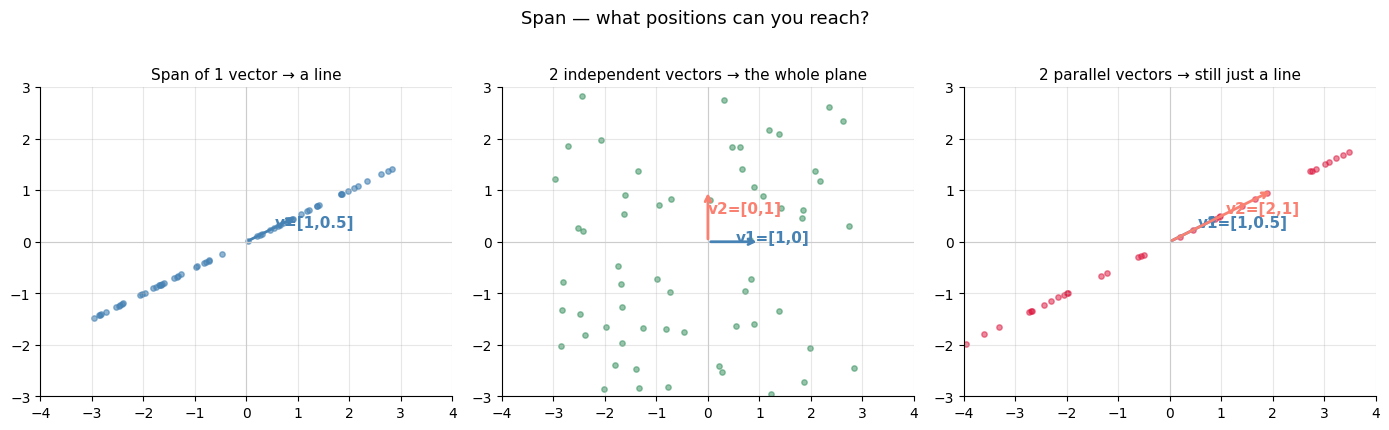

In [9]:
import random
random.seed(42)
scalars = [random.uniform(-3, 3) for _ in range(60)]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Case 1: one vector → a line
v = [1, 0.5]
pts = [(s*v[0], s*v[1]) for s in scalars]
axes[0].scatter([p[0] for p in pts], [p[1] for p in pts], s=15, color='steelblue', alpha=0.6)
draw_vector(axes[0], v, color='steelblue', label='v=[1,0.5]')
axes[0].set_title('Span of 1 vector → a line', fontsize=11)
setup_axes(axes[0], xlim=(-4, 4), ylim=(-3, 3))

# Case 2: two independent vectors → the whole plane
v1, v2 = [1, 0], [0, 1]
pts = [(a*v1[0]+b*v2[0], a*v1[1]+b*v2[1]) for a, b in zip(scalars, scalars[::-1])]
axes[1].scatter([p[0] for p in pts], [p[1] for p in pts], s=15, color='seagreen', alpha=0.5)
draw_vector(axes[1], v1, color='steelblue', label='v1=[1,0]')
draw_vector(axes[1], v2, color='salmon',    label='v2=[0,1]')
axes[1].set_title('2 independent vectors → the whole plane', fontsize=11)
setup_axes(axes[1], xlim=(-4, 4), ylim=(-3, 3))

# Case 3: two parallel vectors → still a line (v2 = 2·v1, no new direction)
v1, v2 = [1, 0.5], [2, 1]
pts = [(a*v1[0]+b*v2[0], a*v1[1]+b*v2[1]) for a, b in zip(scalars, scalars[::-1])]
axes[2].scatter([p[0] for p in pts], [p[1] for p in pts], s=15, color='crimson', alpha=0.5)
draw_vector(axes[2], v1, color='steelblue', label='v1=[1,0.5]')
draw_vector(axes[2], v2, color='salmon',    label='v2=[2,1]')
axes[2].set_title('2 parallel vectors → still just a line', fontsize=11)
setup_axes(axes[2], xlim=(-4, 4), ylim=(-3, 3))

plt.suptitle('Span — what positions can you reach?', fontsize=13)
plt.tight_layout();  plt.show()

---
## 8. Vectors as Data

The most powerful idea in this notebook: **represent any object as a list of numbers**, and you can immediately apply all of linear algebra to it.

Each number measures one attribute of the object. The resulting vector places the object as a **point in multi-dimensional space**. Objects that are close together have similar attribute profiles; objects far apart are different.

**Real-world examples:**

- **Music recommendation:** Spotify represents every song as a vector of   audio features — `[energy, acousticness, danceability, loudness, tempo, ...]`.   When you like a song, the system finds other songs with similar vectors   (close in this feature space) and recommends them. This is how "Discover   Weekly" works.
- **Spam filtering:** An email is converted to a vector where each dimension   counts how often a particular word appears. A spam email has high values   for words like "FREE", "CLICK", "WINNER". A classifier learns a boundary   in this vector space that separates spam from legitimate email.
- **Medical diagnosis:** A patient is described by a vector of test results   `[blood_pressure, glucose, cholesterol, ...]`. Machine learning models   find regions of this space that correspond to different diagnoses — the   geometry of the data reveals the medicine.

In the example below, each student is a 2D vector `[study_hours, sleep_hours]`. Students close together on the plot have similar habits. The dot product between two students' vectors is a raw similarity score — higher means more alike (though for real recommendation systems you would use cosine similarity between normalised vectors).

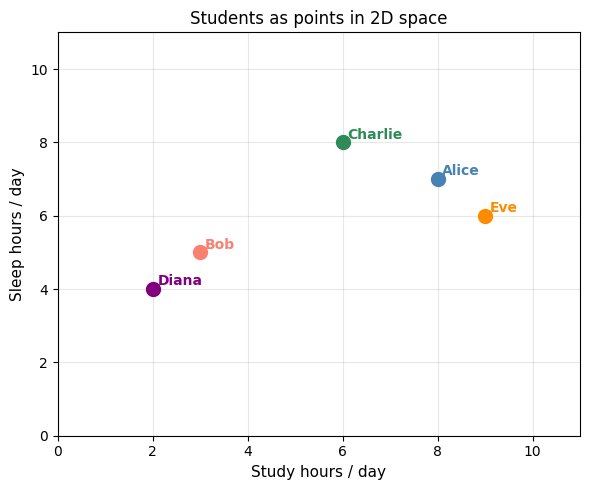

Alice · Bob      =  59.0
Alice · Charlie  = 104.0
Alice · Diana    =  44.0
Alice · Eve      = 114.0


In [10]:
students = {
    'Alice':   [8, 7],
    'Bob':     [3, 5],
    'Charlie': [6, 8],
    'Diana':   [2, 4],
    'Eve':     [9, 6],
}

fig, ax = plt.subplots(figsize=(6, 5))
for (name, vec), col in zip(students.items(),
                             ['steelblue', 'salmon', 'seagreen', 'purple', 'darkorange']):
    ax.plot(*vec, 'o', color=col, markersize=10)
    ax.text(vec[0]+0.1, vec[1]+0.1, name, color=col, fontsize=10, fontweight='bold')

ax.set_xlabel('Study hours / day', fontsize=11)
ax.set_ylabel('Sleep hours / day', fontsize=11)
ax.set_title('Students as points in 2D space', fontsize=12)
ax.grid(True, alpha=0.3);  ax.set_xlim(0, 11);  ax.set_ylim(0, 11)
plt.tight_layout();  plt.show()

# Dot product as a similarity score relative to Alice
alice = students['Alice']
for name, vec in students.items():
    if name != 'Alice':
        print(f"Alice · {name:<8} = {dot(alice, vec):5.1f}")

---
## 9. Linear Transformations

A **linear transformation** is a function that moves every point in space to a new location, using the same rule for every single point. We write that rule as a **matrix multiplication**:

```
[a  b] [x]     [ax + by]
[c  d] [y]  =  [cx + dy]
```

Two properties always hold: **straight lines stay straight** (they may rotate or stretch, but never bend), and **the origin never moves**.

The columns of the matrix tell you where the two basis arrows `[1, 0]` and `[0, 1]` end up after the transformation — every other point follows automatically from those two.

**Real-world examples:**

- **Image editing:** Rotating a photo 45° applies the same rotation matrix   to every pixel coordinate simultaneously. Zooming in is a scaling matrix.   Italicising text in a word processor applies a shear matrix. All of these   are a single matrix multiply per pixel.
- **3D games and animation:** Every time a character moves, the engine   multiplies the coordinates of every vertex in the character model by a   rotation matrix. Stacking multiple matrices (rotate, then scale, then   translate) produces the combined transform, applied in one pass. Modern   GPUs are designed specifically to perform billions of these multiplications   per second.
- **Neural networks:** A single layer of a neural network is literally a   linear transformation — a matrix multiply — followed by a non-linear   activation. Deep learning stacks dozens of these transformations, each one   reshaping the data's geometry until patterns that were tangled together   become linearly separable.

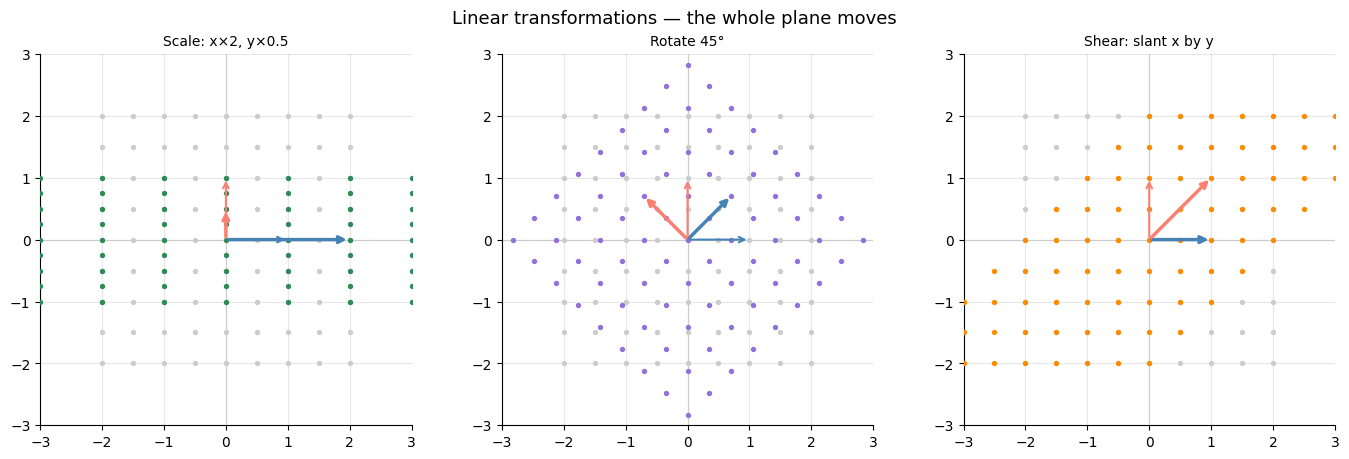

In [11]:
grid_pts = [(x*0.5, y*0.5) for x in range(-4, 5) for y in range(-4, 5)]

angle = math.pi / 4           # 45 degrees
c, s  = math.cos(angle), math.sin(angle)

transforms = [
    ([[2, 0], [0, 0.5]], 'Scale: x×2, y×0.5',  'seagreen'),
    ([[c, -s], [s, c]],  'Rotate 45°',           'mediumpurple'),
    ([[1, 1], [0, 1]],   'Shear: slant x by y',  'darkorange'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, (M, title, color) in zip(axes, transforms):
    ox, oy = zip(*grid_pts)
    tx, ty = zip(*[mat_vec(M, list(p)) for p in grid_pts])
    ax.scatter(ox, oy, s=8, color='#ccc', zorder=2)
    ax.scatter(tx, ty, s=8, color=color, zorder=3)
    for vec, col in [([1, 0], 'steelblue'), ([0, 1], 'salmon')]:
        draw_vector(ax, vec, color=col, lw=1.5)
        draw_vector(ax, mat_vec(M, vec), color=col, lw=2.5)
    ax.set_title(title, fontsize=10)
    setup_axes(ax, xlim=(-3, 3), ylim=(-3, 3))

plt.suptitle('Linear transformations — the whole plane moves', fontsize=13)
plt.tight_layout();  plt.show()

---
## 10. Projection

The **projection** of vector **u** onto vector **v** is the part of **u** that lies in v's direction — imagine a torch shining straight down onto v; the shadow of **u** on the line of **v** is the projection.

`proj_v(u) = (u·v / v·v) × v`

The leftover part — **u minus its projection** — is called the **residual**. It is always exactly perpendicular to **v** (you can verify this: their dot product is zero).

**Real-world examples:**

- **GPS road snapping:** Your GPS records your raw position, but you are   driving on a road. The app needs to show you as a point on the road, not   floating beside it. It projects your position vector onto the direction   vector of the nearest road segment. The projection is the snapped position;   the residual is how far off the road you actually are.
- **Linear regression — fitting a line to data:** When statisticians fit a   straight line to a scatter of points, they are computing a projection.   The observed values form a vector; the best-fit line is the projection   of that vector onto the space of straight-line functions. The residuals   are the vertical distances from each data point to the fitted line —   minimising their squared sum is equivalent to finding the projection.
- **Removing a component from a signal:** An audio engineer wants to remove   the bass from a recording — that is, remove the component of the sound   that points in the "bass direction". They project the signal onto the bass   frequency vector and subtract the result. What remains is the signal with   bass removed. This is the principle behind equaliser filters.

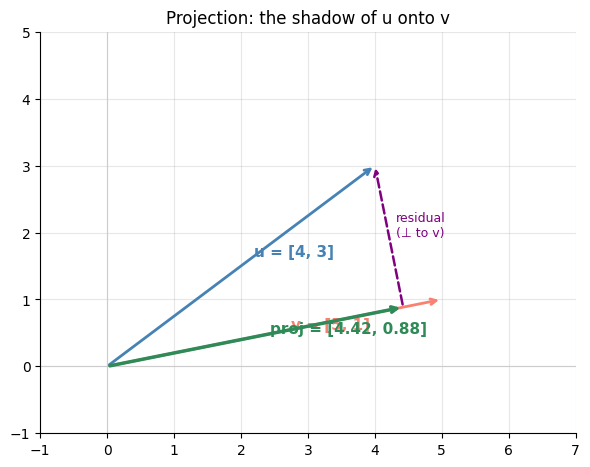

proj     = [4.423, 0.885]
residual = [-0.423, 2.115]
dot(proj, residual) = -0.0  ← should be ~0 (perpendicular)


In [12]:
u = [4, 3]
v = [5, 1]
p     = proj(u, v)
resid = subtract(u, p)

fig, ax = plt.subplots(figsize=(6, 6))
draw_vector(ax, u, color='steelblue', label=f'u = {u}')
draw_vector(ax, v, color='salmon',    label=f'v = {v}')
draw_vector(ax, p, color='seagreen',  label=f'proj = {[round(x, 2) for x in p]}', lw=2.5)
ax.annotate('', xy=(u[0], u[1]), xytext=(p[0], p[1]),
            arrowprops=dict(arrowstyle='->', color='purple', lw=1.8, linestyle='dashed'))
ax.text((p[0]+u[0])/2 + 0.1, (p[1]+u[1])/2,
        'residual\n(⊥ to v)', color='purple', fontsize=9)

setup_axes(ax, xlim=(-1, 7), ylim=(-1, 5))
ax.set_title('Projection: the shadow of u onto v', fontsize=12)
plt.tight_layout();  plt.show()

print(f"proj     = {[round(x, 3) for x in p]}")
print(f"residual = {[round(x, 3) for x in resid]}")
print(f"dot(proj, residual) = {round(dot(p, resid), 10)}  ← should be ~0 (perpendicular)")

---
## Summary

| Concept | In a nutshell |
|---|---|
| **Vector** | A list of numbers — an arrow in space |
| **Addition** | Add components; follow one arrow then the other |
| **Scalar multiplication** | Multiply all components by one number; stretch, shrink, or flip |
| **Dot product** | Sum of matched-component products; measures directional agreement |
| **Cross product** | 3D only; perpendicular vector whose length equals the parallelogram area |
| **Unit vector** | Length = 1; pure direction, no magnitude |
| **Normalisation** | Divide by length to get the unit vector |
| **Span** | All points reachable by scaling and adding a set of vectors |
| **Feature vector** | A data point written as a list of numbers |
| **Linear transformation** | Matrix × vector remaps the whole plane consistently |
| **Projection** | The shadow of one vector onto another; residual is perpendicular |